In [1]:
"""
Müşteri Ayrılma Tahmini - Uçtan Uca Makine Öğrenmesi Projesi

Amaç:
Bu projede müşteri bilgileri kullanılarak müşterinin hizmetten ayrılıp
ayrılmayacağını tahmin eden bir sınıflandırma modeli geliştirilecektir.

Kullanılan temel kütüphaneler:
- pandas
- numpy
- matplotlib
- scikit-learn

Çalıştırma:
Notebook hücreleri yukarıdan aşağıya sırasıyla çalıştırılmalıdır.
"""

'\nMüşteri Ayrılma Tahmini - Uçtan Uca Makine Öğrenmesi Projesi\n\nAmaç:\nBu projede müşteri bilgileri kullanılarak müşterinin hizmetten ayrılıp\nayrılmayacağını tahmin eden bir sınıflandırma modeli geliştirilecektir.\n\nKullanılan temel kütüphaneler:\n- pandas\n- numpy\n- matplotlib\n- scikit-learn\n\nÇalıştırma:\nNotebook hücreleri yukarıdan aşağıya sırasıyla çalıştırılmalıdır.\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sonuçların her çalıştırmada aynı olması için
np.random.seed(42)

# Veri sayısı
n = 1500

# Temel müşteri bilgileri
age = np.random.randint(18, 80, n)
tenure_months = np.random.randint(1, 73, n)

contract_type = np.random.choice(
    ["Month-to-month", "One year", "Two year"],
    n,
    p=[0.55, 0.25, 0.20]
)

internet_service = np.random.choice(
    ["Fiber optic", "DSL", "No"],
    n,
    p=[0.50, 0.40, 0.10]
)

payment_method = np.random.choice(
    [
        "Electronic check",
        "Credit card",
        "Bank transfer",
        "Mailed check"
    ],
    n
)

support_calls = np.random.randint(0, 7, n)
num_services = np.random.randint(1, 9, n)

autopay = np.random.choice([0, 1], n)

# Aylık ücret oluşturma
monthly_charges = (
    25
    + num_services * 7
    + np.where(internet_service == "Fiber optic", 30, 0)
    + np.where(internet_service == "DSL", 15, 0)
    + np.random.normal(0, 8, n)
)

monthly_charges = np.round(
    np.clip(monthly_charges, 20, 150),
    2
)

# Toplam ödeme
total_charges = (
    monthly_charges
    * tenure_months
    * np.random.uniform(0.95, 1.05, n)
)

total_charges = np.round(total_charges, 2)

# Müşterinin ayrılma ihtimali
score = (
    -1.2
    + 1.0 * (contract_type == "Month-to-month")
    + 0.4 * (internet_service == "Fiber optic")
    + 0.15 * support_calls
    - 0.025 * tenure_months
    + 0.006 * (monthly_charges - 70)
    - 0.4 * autopay
)

probability = 1 / (1 + np.exp(-score))

churn = (
    np.random.random(n) < probability
).astype(int)

# DataFrame oluşturma
df = pd.DataFrame({

    "customer_id":
        ["CUST_" + str(i).zfill(5)
         for i in range(1, n + 1)],

    "age": age,

    "tenure_months":
        tenure_months,

    "monthly_charges":
        monthly_charges,

    "total_charges":
        total_charges,

    "contract_type":
        contract_type,

    "internet_service":
        internet_service,

    "payment_method":
        payment_method,

    "support_calls":
        support_calls,

    "num_services":
        num_services,

    "autopay":
        autopay,

    "churn":
        churn
})

# Bazı eksik değerler ekliyoruz
for column in [
    "age",
    "internet_service",
    "payment_method",
    "total_charges"
]:

    missing_rows = np.random.choice(
        df.index,
        size=10,
        replace=False
    )

    df.loc[
        missing_rows,
        column
    ] = np.nan

print("Veri seti başarıyla oluşturuldu.")
print("Veri seti boyutu:", df.shape)

df.head()

Veri seti başarıyla oluşturuldu.
Veri seti boyutu: (1500, 12)


,customer_id,age,tenure_months,monthly_charges,total_charges,contract_type,internet_service,payment_method,support_calls,num_services,autopay,churn
0,CUST_00001,56.0,45,59.10,2658.71,Month-to-month,DSL,Electronic check,5,1,1,0
1,CUST_00002,69.0,2,87.95,167.67,Month-to-month,Fiber optic,Bank transfer,3,6,0,1
2,CUST_00003,46.0,27,49.49,1351.24,One year,DSL,Mailed check,5,2,0,0
3,CUST_00004,32.0,36,94.04,3458.62,One year,Fiber optic,Bank transfer,4,6,0,0
4,CUST_00005,60.0,36,45.78,1634.36,One year,DSL,Mailed check,2,1,0,1


## Veri Seti ve Problem Tanımı

Bu projede müşteri ayrılma (Customer Churn) problemi ele alınmaktadır.

Amaç, müşterilerin yaş, abonelik süresi, aylık ücret, sözleşme türü,
internet hizmeti, ödeme yöntemi ve destek çağrısı gibi özelliklerini
kullanarak hizmetten ayrılıp ayrılmayacaklarını tahmin etmektir.

Hedef değişken: **churn**

- 0: Müşteri ayrılmadı
- 1: Müşteri ayrıldı

Bu nedenle problem bir **ikili sınıflandırma (Binary Classification)** problemidir.

In [3]:
# 2. Veri setinin açıklanması

print("""
Bu projede müşteri ayrılma (Customer Churn) problemi ele alınmaktadır.

Veri setinde müşterilerin yaşı, abonelik süresi, aylık ücreti,
sözleşme türü, internet hizmeti, ödeme yöntemi ve destek çağrıları
gibi bilgiler bulunmaktadır.

Amaç, bu bilgiler kullanılarak müşterinin hizmetten ayrılıp
ayrılmayacağını tahmin etmektir.
""")

df.head()


Bu projede müşteri ayrılma (Customer Churn) problemi ele alınmaktadır.

Veri setinde müşterilerin yaşı, abonelik süresi, aylık ücreti,
sözleşme türü, internet hizmeti, ödeme yöntemi ve destek çağrıları
gibi bilgiler bulunmaktadır.

Amaç, bu bilgiler kullanılarak müşterinin hizmetten ayrılıp
ayrılmayacağını tahmin etmektir.



,customer_id,age,tenure_months,monthly_charges,total_charges,contract_type,internet_service,payment_method,support_calls,num_services,autopay,churn
0,CUST_00001,56.0,45,59.10,2658.71,Month-to-month,DSL,Electronic check,5,1,1,0
1,CUST_00002,69.0,2,87.95,167.67,Month-to-month,Fiber optic,Bank transfer,3,6,0,1
2,CUST_00003,46.0,27,49.49,1351.24,One year,DSL,Mailed check,5,2,0,0
3,CUST_00004,32.0,36,94.04,3458.62,One year,Fiber optic,Bank transfer,4,6,0,0
4,CUST_00005,60.0,36,45.78,1634.36,One year,DSL,Mailed check,2,1,0,1


In [4]:
# 3. Hedef değişken ve problem türü

target = "churn"

print("Hedef değişken:", target)
print("Problem türü: Sınıflandırma")
print("Sınıflandırma türü: İkili sınıflandırma (Binary Classification)")
print("0 = Müşteri ayrılmadı")
print("1 = Müşteri ayrıldı")

Hedef değişken: churn
Problem türü: Sınıflandırma
Sınıflandırma türü: İkili sınıflandırma (Binary Classification)
0 = Müşteri ayrılmadı
1 = Müşteri ayrıldı


In [5]:
# 4. Veri setinin temel olarak incelenmesi

print("İlk 5 satır:")
display(df.head())

print("\nVeri seti boyutu:")
print("Satır sayısı:", df.shape[0])
print("Sütun sayısı:", df.shape[1])

print("\nVeri tipleri:")
print(df.dtypes)

print("\nTemel istatistikler:")
display(df.describe())

İlk 5 satır:


,customer_id,age,tenure_months,monthly_charges,total_charges,contract_type,internet_service,payment_method,support_calls,num_services,autopay,churn
0,CUST_00001,56.0,45,59.10,2658.71,Month-to-month,DSL,Electronic check,5,1,1,0
1,CUST_00002,69.0,2,87.95,167.67,Month-to-month,Fiber optic,Bank transfer,3,6,0,1
2,CUST_00003,46.0,27,49.49,1351.24,One year,DSL,Mailed check,5,2,0,0
3,CUST_00004,32.0,36,94.04,3458.62,One year,Fiber optic,Bank transfer,4,6,0,0
4,CUST_00005,60.0,36,45.78,1634.36,One year,DSL,Mailed check,2,1,0,1



Veri seti boyutu:
Satır sayısı: 1500
Sütun sayısı: 12

Veri tipleri:
customer_id          object
age                 float64
tenure_months         int64
monthly_charges     float64
total_charges       float64
contract_type        object
internet_service     object
payment_method       object
support_calls         int64
num_services          int64
autopay               int64
churn                 int64
dtype: object

Temel istatistikler:


,age,tenure_months,monthly_charges,total_charges,support_calls,num_services,autopay,churn
count,1490.000000,1500.000000,1500.000000,1490.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,49.151678,35.654000,76.700987,2738.058215,2.978000,4.368667,0.472000,0.293333
std,18.132594,20.645931,20.977800,1808.697797,2.019299,2.322430,0.499382,0.455442
min,18.000000,1.000000,20.000000,20.100000,0.000000,1.000000,0.000000,0.000000
25%,34.000000,18.000000,62.250000,1226.482500,1.000000,2.000000,0.000000,0.000000
50%,49.500000,35.000000,77.070000,2449.055000,3.000000,4.000000,0.000000,0.000000
75%,65.000000,54.000000,92.312500,4055.507500,5.000000,6.000000,1.000000,1.000000
max,79.000000,72.000000,132.780000,8242.060000,6.000000,8.000000,1.000000,1.000000


In [6]:
# 5. Eksik değerlerin kontrol edilmesi

print("Eksik değer sayıları:")
print(df.isnull().sum())

Eksik değer sayıları:
customer_id          0
age                 10
tenure_months        0
monthly_charges      0
total_charges       10
contract_type        0
internet_service    10
payment_method      10
support_calls        0
num_services         0
autopay              0
churn                0
dtype: int64


In [7]:
# 5. Eksik değerlerin doldurulması

# Sayısal değişkenleri medyan ile doldurma
df["age"] = df["age"].fillna(df["age"].median())
df["total_charges"] = df["total_charges"].fillna(df["total_charges"].median())

# Kategorik değişkenleri en sık görülen değer (mod) ile doldurma
df["internet_service"] = df["internet_service"].fillna(
    df["internet_service"].mode()[0]
)

df["payment_method"] = df["payment_method"].fillna(
    df["payment_method"].mode()[0]
)

# Kontrol
print("Eksik değerlerin son durumu:")
print(df.isnull().sum())

Eksik değerlerin son durumu:
customer_id         0
age                 0
tenure_months       0
monthly_charges     0
total_charges       0
contract_type       0
internet_service    0
payment_method      0
support_calls       0
num_services        0
autopay             0
churn               0
dtype: int64


In [8]:
# 6. Kategorik değişkenlerin sayısal forma dönüştürülmesi

df_encoded = pd.get_dummies(
    df,
    columns=[
        "contract_type",
        "internet_service",
        "payment_method"
    ],
    drop_first=True
)

print("Encoding sonrası veri seti boyutu:", df_encoded.shape)

df_encoded.head()

Encoding sonrası veri seti boyutu: (1500, 16)


,customer_id,age,tenure_months,monthly_charges,total_charges,support_calls,num_services,autopay,churn,contract_type_One year,contract_type_Two year,internet_service_Fiber optic,internet_service_No,payment_method_Credit card,payment_method_Electronic check,payment_method_Mailed check
0,CUST_00001,56.0,45,59.10,2658.71,5,1,1,0,False,False,False,False,False,True,False
1,CUST_00002,69.0,2,87.95,167.67,3,6,0,1,False,False,True,False,False,False,False
2,CUST_00003,46.0,27,49.49,1351.24,5,2,0,0,True,False,False,False,False,False,True
3,CUST_00004,32.0,36,94.04,3458.62,4,6,0,0,True,False,True,False,False,False,False
4,CUST_00005,60.0,36,45.78,1634.36,2,1,0,1,True,False,False,False,False,False,True


In [9]:
# 7. Aykırı değerlerin incelenmesi

sayisal_sutunlar = [
    "age",
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "support_calls",
    "num_services"
]

for sutun in sayisal_sutunlar:
    Q1 = df_encoded[sutun].quantile(0.25)
    Q3 = df_encoded[sutun].quantile(0.75)
    IQR = Q3 - Q1

    alt_sinir = Q1 - 1.5 * IQR
    ust_sinir = Q3 + 1.5 * IQR

    aykiri_sayisi = df_encoded[
        (df_encoded[sutun] < alt_sinir) |
        (df_encoded[sutun] > ust_sinir)
    ].shape[0]

    print(f"{sutun}: {aykiri_sayisi} aykırı değer")

age: 0 aykırı değer
tenure_months: 0 aykırı değer
monthly_charges: 0 aykırı değer
total_charges: 0 aykırı değer
support_calls: 0 aykırı değer
num_services: 0 aykırı değer


In [10]:
# 8. Sayısal değişkenlerin ölçeklenmesi

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

olceklenecek_sutunlar = [
    "age",
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "support_calls",
    "num_services"
]

df_encoded[olceklenecek_sutunlar] = scaler.fit_transform(
    df_encoded[olceklenecek_sutunlar]
)

print("Sayısal değişkenler StandardScaler ile ölçeklendirildi.")

df_encoded[olceklenecek_sutunlar].head()

Sayısal değişkenler StandardScaler ile ölçeklendirildi.


,age,tenure_months,monthly_charges,total_charges,support_calls,num_services
0,0.378944,0.452831,-0.839309,-0.042959,1.001672,-1.450976
1,1.098527,-1.630599,0.536413,-1.425176,0.010899,0.702659
2,-0.174582,-0.419302,-1.297565,-0.768442,1.001672,-1.020249
3,-0.949518,0.016764,0.826817,0.400891,0.506285,0.702659
4,0.600354,0.016764,-1.474478,-0.611346,-0.484488,-1.450976


In [11]:
# 9. Öznitelik mühendisliği

# Müşterinin kullandığı her hizmet başına ödediği ortalama ücret
df_encoded["charge_per_service"] = (
    df["monthly_charges"] / df["num_services"]
)

# Müşterinin abonelik süresine göre destek çağrısı oranı
df_encoded["support_call_rate"] = (
    df["support_calls"] / df["tenure_months"]
)

print("Yeni öznitelikler oluşturuldu:")
print("- charge_per_service")
print("- support_call_rate")

df_encoded[
    ["charge_per_service", "support_call_rate"]
].head()

Yeni öznitelikler oluşturuldu:
- charge_per_service
- support_call_rate


,charge_per_service,support_call_rate
0,59.100000,0.111111
1,14.658333,1.500000
2,24.745000,0.185185
3,15.673333,0.111111
4,45.780000,0.055556


In [12]:
# 10. Öznitelik seçimi - Korelasyon analizi

# customer_id modelde anlamlı olmadığı için analize dahil edilmiyor
korelasyon_df = df_encoded.drop(columns=["customer_id"])

# Değişkenlerin churn ile korelasyonları
korelasyonlar = (
    korelasyon_df.corr()["churn"]
    .drop("churn")
    .abs()
    .sort_values(ascending=False)
)

print("Churn ile en yüksek korelasyona sahip özellikler:")
print(korelasyonlar)

# En yüksek korelasyona sahip ilk 10 özellik seçiliyor
selected_features = korelasyonlar.head(10).index.tolist()

print("\nSeçilen özellikler:")
for feature in selected_features:
    print("-", feature)

Churn ile en yüksek korelasyona sahip özellikler:
tenure_months                      0.236802
total_charges                      0.181336
support_call_rate                  0.145234
contract_type_One year             0.132999
contract_type_Two year             0.118953
support_calls                      0.100596
internet_service_Fiber optic       0.075703
autopay                            0.066524
internet_service_No                0.065772
monthly_charges                    0.063362
payment_method_Mailed check        0.057041
charge_per_service                 0.025525
payment_method_Credit card         0.013388
age                                0.010597
payment_method_Electronic check    0.007535
num_services                       0.004280
Name: churn, dtype: float64

Seçilen özellikler:
- tenure_months
- total_charges
- support_call_rate
- contract_type_One year
- contract_type_Two year
- support_calls
- internet_service_Fiber optic
- autopay
- internet_service_No
- monthly_charge

In [13]:
# 11. Verinin train, validation ve test kümelerine ayrılması

from sklearn.model_selection import train_test_split

# Seçilen özellikler
X = df_encoded[selected_features]

# Hedef değişken
y = df_encoded["churn"]

# Önce %20 test ayırıyoruz
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Kalan %80 veriden validation ayırıyoruz
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

print("Train boyutu:", X_train.shape)
print("Validation boyutu:", X_val.shape)
print("Test boyutu:", X_test.shape)

Train boyutu: (900, 10)
Validation boyutu: (300, 10)
Test boyutu: (300, 10)


In [14]:
# 12. Farklı makine öğrenmesi modellerinin eğitilmesi

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Modeller
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
decision_tree_model = DecisionTreeClassifier(random_state=42)
random_forest_model = RandomForestClassifier(random_state=42)

# Eğitim
logistic_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("3 model başarıyla eğitildi:")
print("- Logistic Regression")
print("- Decision Tree")
print("- Random Forest")

3 model başarıyla eğitildi:
- Logistic Regression
- Decision Tree
- Random Forest


In [15]:
# 13. Modellerin validation performanslarının karşılaştırılması

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

sonuclar = []

for model_adi, model in models.items():
    y_pred = model.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    sonuclar.append({
        "Model": model_adi,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

sonuc_df = pd.DataFrame(sonuclar)

print("Validation sonuçları:")
display(sonuc_df.sort_values(by="F1 Score", ascending=False))

Validation sonuçları:


,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.626667,0.386792,0.465909,0.422680
2,Random Forest,0.740000,0.631579,0.272727,0.380952
0,Logistic Regression,0.716667,0.542857,0.215909,0.308943


In [16]:
# 14. En iyi model için hiperparametre ayarlama

from sklearn.model_selection import GridSearchCV

# Validation sonuçlarına göre en iyi modeli bul
en_iyi_model_adi = sonuc_df.loc[
    sonuc_df["F1 Score"].idxmax(),
    "Model"
]

print("Validation sonucuna göre en iyi model:", en_iyi_model_adi)

# En iyi modele göre parametre aralığı belirleme
if en_iyi_model_adi == "Logistic Regression":

    model = LogisticRegression(max_iter=1000, random_state=42)

    param_grid = {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear", "lbfgs"]
    }

elif en_iyi_model_adi == "Decision Tree":

    model = DecisionTreeClassifier(random_state=42)

    param_grid = {
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    }

else:

    model = RandomForestClassifier(random_state=42)

    param_grid = {
        "n_estimators": [100, 200],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5]
    }

# 5 katlı çapraz doğrulama ile Grid Search
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("\nEn iyi parametreler:")
print(grid_search.best_params_)

print("\nEn iyi çapraz doğrulama F1 skoru:")
print(grid_search.best_score_)

Validation sonucuna göre en iyi model: Decision Tree

En iyi parametreler:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}

En iyi çapraz doğrulama F1 skoru:
0.3678786526124993


In [17]:
# 15. En iyi modelin test verisi üzerinde değerlendirilmesi

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Test tahminleri
y_test_pred = best_model.predict(X_test)

# Metrikler
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)

print("Test Sonuçları")
print("----------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Test Sonuçları
----------------------------
Accuracy : 0.63
Precision: 0.3175
Recall   : 0.2273
F1 Score : 0.2649

Confusion Matrix:
[[169  43]
 [ 68  20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.80      0.75       212
           1       0.32      0.23      0.26        88

    accuracy                           0.63       300
   macro avg       0.52      0.51      0.51       300
weighted avg       0.60      0.63      0.61       300



In [18]:
# 16. Model sonuçlarının yorumlanması

print("MODEL SONUÇ YORUMU")
print("----------------------------")

print(f"Validation sonuçlarına göre en başarılı model: {en_iyi_model_adi}")

print(f"""
Test verisi üzerinde modelin performansı:

Accuracy : {accuracy:.4f}
Precision: {precision:.4f}
Recall   : {recall:.4f}
F1 Score : {f1:.4f}

Model karşılaştırmasında F1 Score temel alınmış ve validation
verisinde en yüksek F1 değerine sahip model seçilmiştir.

Öznitelik seçimi aşamasında churn değişkeniyle ilişkisi yüksek olan
özellikler modele dahil edilmiştir.

Öne çıkan bazı özellikler:
{selected_features[:5]}

Modelin sınırlılıkları:
- Kullanılan veri seti sınırlı sayıda müşteri özelliği içermektedir.
- Veri seti proje kapsamında oluşturulmuştur ve gerçek şirket verilerini temsil etmemektedir.
- Gerçek hayatta müşteri davranışını etkileyen daha fazla değişken bulunabilir.
- Model farklı veri setlerinde aynı performansı göstermeyebilir.

Sonuç olarak model, müşteri ayrılma tahmini için kullanılabilir bir
başlangıç modeli sunmaktadır. Daha fazla gerçek veri ve ek özelliklerle
model performansı geliştirilebilir.
""")

MODEL SONUÇ YORUMU
----------------------------
Validation sonuçlarına göre en başarılı model: Decision Tree

Test verisi üzerinde modelin performansı:

Accuracy : 0.6300
Precision: 0.3175
Recall   : 0.2273
F1 Score : 0.2649

Model karşılaştırmasında F1 Score temel alınmış ve validation
verisinde en yüksek F1 değerine sahip model seçilmiştir.

Öznitelik seçimi aşamasında churn değişkeniyle ilişkisi yüksek olan
özellikler modele dahil edilmiştir.

Öne çıkan bazı özellikler:
['tenure_months', 'total_charges', 'support_call_rate', 'contract_type_One year', 'contract_type_Two year']

Modelin sınırlılıkları:
- Kullanılan veri seti sınırlı sayıda müşteri özelliği içermektedir.
- Veri seti proje kapsamında oluşturulmuştur ve gerçek şirket verilerini temsil etmemektedir.
- Gerçek hayatta müşteri davranışını etkileyen daha fazla değişken bulunabilir.
- Model farklı veri setlerinde aynı performansı göstermeyebilir.

Sonuç olarak model, müşteri ayrılma tahmini için kullanılabilir bir
başlangıç mo

En önemli özellikler:


,Ozellik,Onem
1,total_charges,0.272496
9,monthly_charges,0.225789
2,support_call_rate,0.214770
0,tenure_months,0.118274
5,support_calls,0.057135
6,internet_service_Fiber optic,0.051819
4,contract_type_Two year,0.028001
3,contract_type_One year,0.026079
7,autopay,0.004637
8,internet_service_No,0.001001


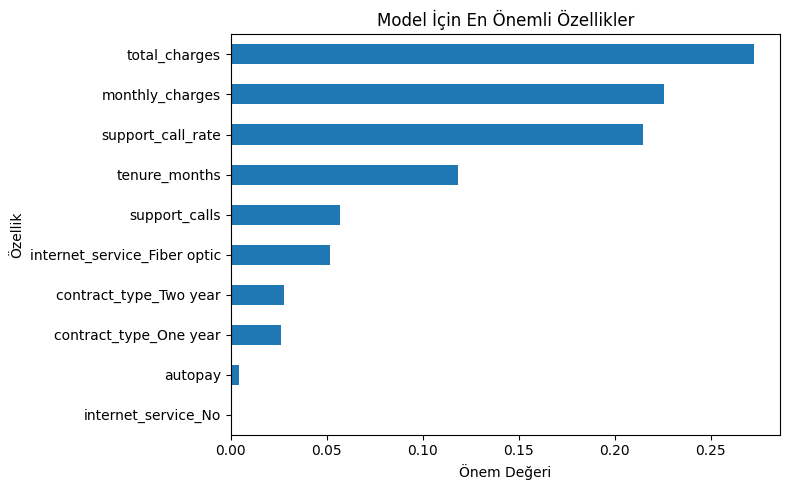

In [19]:
# 17. BONUS - Model açıklanabilirliği

import pandas as pd
import matplotlib.pyplot as plt

if hasattr(best_model, "feature_importances_"):
    onem_degerleri = best_model.feature_importances_

elif hasattr(best_model, "coef_"):
    onem_degerleri = abs(best_model.coef_[0])

else:
    onem_degerleri = None


if onem_degerleri is not None:

    feature_importance_df = pd.DataFrame({
        "Ozellik": X_train.columns,
        "Onem": onem_degerleri
    })

    feature_importance_df = feature_importance_df.sort_values(
        by="Onem",
        ascending=False
    )

    print("En önemli özellikler:")
    display(feature_importance_df.head(10))

    feature_importance_df.head(10).sort_values(
        by="Onem"
    ).plot(
        x="Ozellik",
        y="Onem",
        kind="barh",
        legend=False,
        figsize=(8, 5)
    )

    plt.title("Model İçin En Önemli Özellikler")
    plt.xlabel("Önem Değeri")
    plt.ylabel("Özellik")
    plt.tight_layout()
    plt.show()

else:
    print("Bu model için doğrudan özellik önemi hesaplanamadı.")